# Cascade-Mind GRPO Training — Final v2

**Model**: `unsloth/mistral-7b-instruct-v0.3`  
**Framework**: Unsloth + TRL 0.22.2 (pinned)  
**Training**: Real GRPO — conversational incident prompts, multi-turn env rollouts in reward functions

### Root-cause fixes applied vs earlier notebooks
| Issue | Fix |
|-------|-----|
| `max_prompt_length` missing → shuffle_sequence_dict OOB CUDA assert | Set `max_prompt_length=512` in GRPOConfig |
| `fast_inference=True` (vLLM) → `output_scores=True` not supported | `fast_inference=False` (standard transformers generate) |
| Reward functions returned 0 → all rewards identical → advantage=0 → collapse | `_run_episode()` runs real env turns 2-3 with `model.generate(do_sample=True)` |
| `trainer.train()` never called (Llama-8B v1) — synthetic curves | `trainer.train()` called here — real backprop |
| Greedy fallback always submitted `[]` → fbeta=0.101 constant → reward_std=0 | Turns 2-3 use sampled `model.generate` → different paths → real reward variance |
| All prompts mapped to seed=0 → identical episodes → no diversity | Conversational dataset with `[ID:N]` markers → each prompt uses unique env seed |

In [1]:
%%capture
import os, subprocess, sys

# ── MUST be first — before torch/CUDA is ever imported ───────────────────────
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"   # makes async CUDA errors synchronous
os.environ["TORCH_USE_CUDA_DSA"]   = "1"   # enables device-side assert logging
os.environ["UNSLOTH_VLLM_STANDBY"] = "1"

# ── Clone Cascade-Mind environment ───────────────────────────────────────────
result = subprocess.run(
    ["git", "clone", "--depth=1",
     "https://huggingface.co/spaces/Rajkamal2819/cascade-mind",
     "/content/cascade-mind"],
    capture_output=True, text=True
)
if result.returncode != 0 and "already exists" not in result.stderr:
    print("Clone failed:", result.stderr)

if "/content/cascade-mind" not in sys.path:
    sys.path.insert(0, "/content/cascade-mind")

# ── Domain dependencies ───────────────────────────────────────────────────────
!pip install -q networkx>=3.0 "pydantic>=2.0" "jinja2==3.1.4" huggingface_hub>=0.24.0 datasets

# ── uv for fast package installs ─────────────────────────────────────────────
!pip install --upgrade -qqq uv

## 1. Environment Setup & Dependencies

Install and configure all required packages: Unsloth, TRL 0.22.2, Transformers, and domain utilities.

In [2]:
import subprocess

try:
    is_t4 = "Tesla T4" in str(subprocess.check_output(["nvidia-smi"]))
except Exception:
    is_t4 = False

_vllm   = "vllm==0.9.2"   if is_t4 else "vllm==0.15.1"
_triton = "triton==3.2.0" if is_t4 else "triton"

# Install Unsloth + vLLM (needed by Unsloth even with fast_inference=False for env setup)
!uv pip install -qqq --upgrade {_vllm} torchvision bitsandbytes xformers unsloth
!uv pip install -qqq {_triton}
!uv pip install transformers==4.56.2
!uv pip install --no-deps trl==0.22.2   # pin — rollout_func API tested at this version

# Remove torchcodec: pulled in by sentence_transformers, breaks on T4 (no FFmpeg)
!pip uninstall -y torchcodec sentence-transformers 2>/dev/null || true

print("\n✅ Installed: Unsloth + TRL 0.22.2 + Transformers 4.56.2")
print(f"   GPU type detected: {'T4' if is_t4 else 'other'}")

Using Python 3.12.13 environment at: /usr
Resolved 18 packages in 43ms
Uninstalled 2 packages in 268ms
Installed 2 packages in 381ms
 - huggingface-hub==1.12.0
 + huggingface-hub==0.36.2
 - transformers==5.5.0
 + transformers==4.56.2
Using Python 3.12.13 environment at: /usr
Resolved 1 package in 11ms
Uninstalled 1 package in 9ms
Installed 1 package in 26ms
 - trl==0.24.0
 + trl==0.22.2

✅ Installed: Unsloth + TRL 0.22.2 + Transformers 4.56.2
   GPU type detected: T4


## 2. HF Authentication

Log in to Hugging Face Hub via `HF_TOKEN` (optional — Mistral-7B-Instruct-v0.3 is Apache 2.0, no token required).

In [3]:
import os
from huggingface_hub import login, whoami

# Set via Colab Secrets (🔑 icon in sidebar → add HF_TOKEN) or environment variable
HF_TOKEN = os.environ.get("HF_TOKEN", "")

if HF_TOKEN:
    login(token=HF_TOKEN, add_to_git_credential=False)
    try:
        me = whoami(token=HF_TOKEN)
        print(f"✅ Logged in as: {me['name']}")
    except Exception as e:
        print(f"⚠️  Login check failed: {e}")
else:
    print("ℹ️  No HF_TOKEN — proceeding anonymously (fine for Mistral, Apache 2.0)")

ℹ️  No HF_TOKEN — proceeding anonymously (fine for Mistral, Apache 2.0)


## 3. Runtime Health Check

Auto-restart kernel if C-extension packages (numpy, torch) were upgraded during install, ensuring correct versions are loaded before training.

In [4]:
# Auto-restart if C-extension packages were upgraded (numpy, etc.)
import importlib, sys

def _pkg_version(name):
    try:
        import importlib.metadata
        return importlib.metadata.version(name)
    except Exception:
        return None

import numpy as np
installed_np = _pkg_version("numpy")

if installed_np and np.__version__ != installed_np:
    print(f"⚠️  numpy mismatch: loaded={np.__version__}  installed={installed_np}")
    print("🔄 Restarting runtime — Colab will resume from the next cell...")
    import IPython
    IPython.Application.instance().kernel.do_shutdown(True)
else:
    print(f"✅ numpy consistent ({np.__version__}) — no restart needed")

✅ numpy consistent (2.2.6) — no restart needed


## 4. Cascade-Mind Environment

Initialize the in-process SRE blast-radius environment (`CascadeMindEnvLocal`) — no HTTP, ~10ms per step. Validates reset and step with a smoke test.

In [5]:
import sys, os

# Disable Cerebras LLM calls — use fast deterministic template responses instead
os.environ["LLM_SIMULATOR_ENABLED"] = "false"
os.environ["LLM_CACHE_PATH"] = "/tmp/cascade_mind_cache.json"

if "/content/cascade-mind" not in sys.path:
    sys.path.insert(0, "/content/cascade-mind")

from cascade_mind.server.env.service_impact_environment import ServiceImpactEnvironment
from cascade_mind.models import ServiceImpactAction

VALID_ACTION_TYPES = {
    "query_dependents", "query_dependencies", "query_runbook",
    "query_changelog", "query_monitoring", "query_topology_diff",
    "query_service_health", "submit_hypothesis", "submit",
}


class CascadeMindEnvLocal:
    """In-process wrapper — no HTTP, runs at ~10ms/step."""

    def __init__(self):
        self._env = ServiceImpactEnvironment()

    def reset(self, seed: int = 0) -> dict:
        obs = self._env.reset(seed=seed)
        return {"changed_service": obs.changed_service, "message": obs.message,
                "queries_remaining": obs.queries_remaining, "done": obs.done, "reward": None}

    def step(self, action: dict) -> dict:
        if action.get("action_type") not in VALID_ACTION_TYPES:
            action = {"action_type": "submit", "affected_services": []}
        safe = {"action_type": action["action_type"]}
        if "service_name" in action:
            safe["service_name"] = str(action["service_name"]).lower().strip()
        if "affected_services" in action:
            svcs = action["affected_services"]
            safe["affected_services"] = [str(s).lower().strip() for s in svcs] if isinstance(svcs, list) else []
        if "confidence" in action:
            safe["confidence"] = float(action["confidence"])
        try:
            obs = self._env.step(ServiceImpactAction(**safe))
        except Exception as e:
            return {"changed_service": "", "message": f"Error: {e}",
                    "queries_remaining": 0, "done": True, "reward": 0.0, "intermediate_fbeta": 0.0}
        return {"changed_service": obs.changed_service, "message": obs.message,
                "queries_remaining": obs.queries_remaining, "done": obs.done,
                "reward": obs.reward, "intermediate_fbeta": obs.intermediate_fbeta or 0.0}


# Smoke test
print("Running smoke test...")
_env = CascadeMindEnvLocal()
_obs = _env.reset(seed=0)
print(f"✅ reset OK — changed_service={_obs['changed_service']!r}, budget={_obs['queries_remaining']}")
_step = _env.step({"action_type": "query_dependents", "service_name": _obs["changed_service"]})
print(f"✅ step  OK — done={_step['done']}, reward={_step['reward']}, budget={_step['queries_remaining']}")
del _env, _obs, _step
print("\n✅ In-process environment ready — ~10ms per step")

Running smoke test...
✅ reset OK — changed_service='cart_service', budget=13
✅ step  OK — done=False, reward=0.05, budget=12

✅ In-process environment ready — ~10ms per step


## 5. Load Base Model

Load Mistral-7B-Instruct-v0.3 in 4-bit NF4 quantization with Unsloth (`fast_inference=False` for standard `generate()` + tokenizer safety assertions).

In [6]:
from unsloth import FastLanguageModel
import torch

MODEL_NAME     = "unsloth/mistral-7b-instruct-v0.3"
max_seq_length = 2048   # covers prompt (512) + completion (128) with headroom
lora_rank      = 16

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name             = MODEL_NAME,
    max_seq_length         = max_seq_length,
    load_in_4bit           = True,
    fast_inference         = False,   # FIX: False → standard generate() supports output_scores=True
    max_lora_rank          = lora_rank,
    gpu_memory_utilization = 0.6,
)

# ── Pad token ────────────────────────────────────────────────────────────────
if tokenizer.pad_token_id is None or tokenizer.pad_token_id == tokenizer.eos_token_id:
    tokenizer.pad_token    = tokenizer.unk_token    # <unk>  id=0
    tokenizer.pad_token_id = tokenizer.unk_token_id
tokenizer.padding_side   = "left"   # required for GRPO batch generation
tokenizer.truncation_side = "left"  # keep most-recent context when truncating long prompts

# ── Hard assertions ───────────────────────────────────────────────────────────
assert tokenizer.pad_token_id != tokenizer.eos_token_id, \
    "pad==eos corrupts attention masks — GRPO will crash!"
assert tokenizer.bos_token_id is not None, \
    "bos_token_id must not be None (Mistral: 1)"

model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f"✅ Model on {gpu.name} ({gpu.total_memory/1024**3:.1f} GB)")
    print(f"   Reserved  : {torch.cuda.max_memory_reserved()/1024**3:.2f} GB")
print(f"   vocab_size : {tokenizer.vocab_size:,}")
print(f"   pad_token  : {tokenizer.pad_token!r}  id={tokenizer.pad_token_id}")
print(f"   eos_token  : {tokenizer.eos_token!r}  id={tokenizer.eos_token_id}")
print(f"   bos_id     : {tokenizer.bos_token_id}  ✓ not None")
print(f"   pad ≠ eos  : {tokenizer.pad_token_id != tokenizer.eos_token_id}  ✓")
print(f"   fast_inference=False → output_scores=True supported ✓")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
INFO 04-26 00:06:11 [__init__.py:244] Automatically detected platform cuda.
ERROR 04-26 00:06:21 [fa_utils.py:57] Cannot use FA version 2 is not supported due to FA2 is only supported on devices with compute capability >= 8
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Mistral patching. Transformers: 4.56.2. vLLM: 0.9.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Model on Tesla T4 (14.6 GB)
   Reserved  : 6.73 GB
   vocab_size : 32,768
   pad_token  : '[control_768]'  id=770
   eos_token  : '</s>'  id=2
   bos_id     : 1  ✓ not Non

## 6. System Prompt & Action Parsing

Define the SRE incident-response system prompt and JSON action parser (robust to markdown fences, partial JSON, and missing fields).

In [7]:
import re, json
from typing import Optional

SYSTEM_PROMPT = """You are an expert on-call SRE engineer investigating a P1 service incident.

## SITUATION
A microservice has had a breaking change. Your job is to identify every downstream service
in the blast radius before your query budget runs out.

## AVAILABLE ACTIONS
Output EXACTLY ONE JSON action per turn. Choose from:

1. Query which services call X (costs 1 budget):
   {"action_type": "query_dependents", "service_name": "SERVICE_NAME"}

2. Query what X depends on (costs 1 budget):
   {"action_type": "query_dependencies", "service_name": "SERVICE_NAME"}

3. Read runbook for X (free, max 2 times total):
   {"action_type": "query_runbook", "service_name": "SERVICE_NAME"}

4. Read changelog for X (free, max 2 times total):
   {"action_type": "query_changelog", "service_name": "SERVICE_NAME"}

5. Check monitoring for X (free):
   {"action_type": "query_monitoring", "service_name": "SERVICE_NAME"}

6. Submit final answer (terminal — ends episode):
   {"action_type": "submit", "affected_services": ["svc_a", "svc_b", ...]}

## STRATEGY
- Start with query_dependents on the changed service
- Follow the dependency chain — services that call X are also affected
- Do NOT re-query the same service twice
- Submit when confident — missing a service is worse than a false alarm (β=2)

## OUTPUT FORMAT
Respond with ONLY the JSON action. No explanation. No markdown fences.
"""


def parse_action(text: str) -> Optional[dict]:
    text = text.strip()
    text = re.sub(r"^```(?:json)?\s*", "", text)
    text = re.sub(r"\s*```$", "", text)
    try:
        obj = json.loads(text)
        if isinstance(obj, dict) and "action_type" in obj:
            if "service_name" in obj:
                obj["service_name"] = str(obj["service_name"]).lower().strip()
            if "affected_services" in obj and isinstance(obj["affected_services"], list):
                obj["affected_services"] = [str(s).lower().strip() for s in obj["affected_services"]]
            return obj
    except json.JSONDecodeError:
        pass
    match = re.search(r"\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\}", text, re.DOTALL)
    if match:
        try:
            obj = json.loads(match.group())
            if isinstance(obj, dict) and "action_type" in obj:
                if "service_name" in obj:
                    obj["service_name"] = str(obj["service_name"]).lower().strip()
                if "affected_services" in obj and isinstance(obj["affected_services"], list):
                    obj["affected_services"] = [str(s).lower().strip() for s in obj["affected_services"]]
                return obj
        except json.JSONDecodeError:
            pass
    return None


def build_fallback_action(changed_service: str, queried: set) -> dict:
    if changed_service and changed_service not in queried:
        return {"action_type": "query_dependents", "service_name": changed_service.lower()}
    return {"action_type": "submit", "affected_services": []}


def build_messages(incident_message: str, turn_history: list) -> list:
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    messages.append({"role": "user", "content": (
        f"INCIDENT ALERT:\n{incident_message}\n\nOutput your first action as JSON."
    )})
    for turn in turn_history:
        messages.append({"role": "assistant", "content": turn["action_text"]})
        messages.append({"role": "user", "content": (
            f"Tool result:\n{turn['observation']}\n\n"
            f"Budget remaining: {turn['budget']}\n\nOutput your next action as JSON."
        )})
    return messages


print("✅ System prompt and action helpers defined")

✅ System prompt and action helpers defined


## 7. Episode Execution Helpers

Define `_run_episode()` for 3-turn GRPO training episodes (Turn 1 from TRL, Turns 2–3 from `model.generate`) and `rollout_once()` for 6-turn post-training evaluation.

In [8]:
from collections import defaultdict
import torch.nn.functional as F
import re as _re

MAX_PROMPT_LEN  = 512   # must match GRPOConfig.max_prompt_length
MAX_TOKENS      = 48    # enough for any JSON action (~15 tokens) with headroom
NUM_GENERATIONS = 2     # must match GRPOConfig.num_generations

# Shared episode cache: avoids re-running identical (seed, first_action) pairs
# when 3 reward functions (fbeta, budget, rep) all evaluate the same completion.
_episode_cache: dict = {}


def _run_episode(seed: int, first_action_text: str) -> dict:
    """
    Run a 3-turn episode where:
      - Turn 1: first_action_text (provided by TRL's own generation from the incident prompt)
      - Turns 2–3: model.generate continues the episode from the updated context

    Why this works instead of greedy fallback:
      - Different first actions (from temperature sampling) → different Turn 2/3 paths
      - Different paths → different F-beta scores → reward_std > 0 → real gradients
      - Greedy fallback in the edited notebook always submitted [] → fbeta=0.101 always → collapse
    """
    cache_key = (seed, first_action_text[:120])
    if cache_key in _episode_cache:
        return _episode_cache[cache_key]

    env = CascadeMindEnvLocal()
    obs = env.reset(seed=seed)
    changed_service  = obs["changed_service"]
    max_budget       = obs["queries_remaining"]
    incident_message = obs["message"]

    # Parse and execute the model's TRL-generated first action
    action = parse_action(first_action_text)
    if action is None:
        action = {"action_type": "query_dependents", "service_name": changed_service}

    if action.get("action_type") == "submit":
        result = env.step(action)
        ep = {"fbeta": float(result.get("reward") or 0.0), "budget": 1.0, "rep": 0.0}
        _episode_cache[cache_key] = ep
        return ep

    queried = set()
    svc = action.get("service_name", "")
    if svc:
        queried.add(svc)

    result    = env.step(action)
    done      = result.get("done", False)
    budget_left = result.get("queries_remaining", max_budget)
    turn_history = [{
        "action_text": first_action_text,
        "observation": result.get("message", ""),
        "budget":      budget_left,
    }]

    # ── Turns 2–3: model continues the episode ──────────────────────────────
    for _ in range(2):
        if done or budget_left <= 1:
            break

        messages    = build_messages(incident_message, turn_history)
        prompt_text = tokenizer.apply_chat_template(
            messages, add_generation_prompt=True, tokenize=False
        )
        prompt_tokens = tokenizer(
            prompt_text, return_tensors="pt", truncation=True, max_length=MAX_PROMPT_LEN
        ).input_ids.to(model.device)

        with torch.no_grad():
            out = model.generate(
                prompt_tokens,
                attention_mask=torch.ones_like(prompt_tokens),
                max_new_tokens=MAX_TOKENS,
                temperature=0.7,
                top_p=0.9,
                do_sample=True,
                pad_token_id=tokenizer.pad_token_id,
            )

        next_text   = tokenizer.decode(out[0][prompt_tokens.shape[1]:], skip_special_tokens=True)
        next_action = parse_action(next_text)
        if next_action is None:
            next_action = {"action_type": "submit",
                           "affected_services": list(queried - {changed_service})}

        svc2 = next_action.get("service_name", "")
        if svc2:
            queried.add(svc2)

        result      = env.step(next_action)
        done        = result.get("done", False)
        budget_left = result.get("queries_remaining", 0)
        turn_history.append({
            "action_text": next_text,
            "observation": result.get("message", ""),
            "budget":      budget_left,
        })
        if done:
            break

    # ── Force submit if still not done ───────────────────────────────────────
    if not done:
        affected    = list(queried - {changed_service})
        result      = env.step({"action_type": "submit", "affected_services": affected})
        budget_left = result.get("queries_remaining", 0)

    ep = {
        "fbeta":  float(result.get("reward") or 0.0),
        "budget": max(0.0, budget_left / max(1, max_budget)),
        "rep":    0.0,
    }
    _episode_cache[cache_key] = ep
    return ep


def rollout_once(seed: int) -> dict:
    """Full 6-turn evaluation episode — used ONLY for post-training eval (cell-16)."""
    env = CascadeMindEnvLocal()
    obs = env.reset(seed=seed)
    incident_message = obs["message"]
    changed_service  = obs["changed_service"]
    max_budget       = obs["queries_remaining"]

    turn_history = []
    queried      = set()
    final_reward = 0.0
    done         = False

    for _ in range(6):
        if done:
            break
        messages    = build_messages(incident_message, turn_history)
        prompt_text = tokenizer.apply_chat_template(
            messages, add_generation_prompt=True, tokenize=False
        )
        prompt_tokens = tokenizer(
            prompt_text, return_tensors="pt", truncation=True, max_length=MAX_PROMPT_LEN
        ).input_ids.to(model.device)

        with torch.no_grad():
            out = model.generate(
                prompt_tokens,
                attention_mask=torch.ones_like(prompt_tokens),
                max_new_tokens=MAX_TOKENS,
                temperature=0.7, top_p=0.9, do_sample=True,
                pad_token_id=tokenizer.pad_token_id,
            )

        comp_text = tokenizer.decode(out[0][prompt_tokens.shape[1]:], skip_special_tokens=True)
        action    = parse_action(comp_text)
        if action is None:
            action = {"action_type": "query_dependents", "service_name": changed_service} \
                     if changed_service not in queried \
                     else {"action_type": "submit", "affected_services": list(queried - {changed_service})}

        svc = action.get("service_name", "")
        if svc:
            queried.add(svc)

        result = env.step(action)
        done   = result.get("done", False)
        budget_left = result.get("queries_remaining", 0)
        turn_history.append({"action_text": comp_text,
                              "observation": result.get("message", ""), "budget": budget_left})
        if done and result.get("reward") is not None:
            final_reward = float(result["reward"])
            break

    if not done:
        affected     = list(queried - {changed_service})
        result       = env.step({"action_type": "submit", "affected_services": affected})
        final_reward = float(result.get("reward") or 0.0)

    return {"fbeta_reward": final_reward, "budget_reward": 0.0, "rep_reward": 0.0}


print("✅ _run_episode (training) + rollout_once (eval) defined")
print(f"   MAX_PROMPT_LEN  = {MAX_PROMPT_LEN}  (must == GRPOConfig.max_prompt_length)")
print(f"   MAX_TOKENS      = {MAX_TOKENS}")
print(f"   NUM_GENERATIONS = {NUM_GENERATIONS}  (must == GRPOConfig.num_generations)")

✅ _run_episode (training) + rollout_once (eval) defined
   MAX_PROMPT_LEN  = 512  (must == GRPOConfig.max_prompt_length)
   MAX_TOKENS      = 48
   NUM_GENERATIONS = 2  (must == GRPOConfig.num_generations)


## 8. Reward Functions

Three TRL reward functions: `reward_fbeta` (F-beta β=2, primary signal), `reward_budget` (efficiency bonus ×0.2), `reward_repetition` (placeholder). Cache cleared per reward round to ensure stochastic within-prompt reward variance.

In [9]:
# Reward functions — TRL 0.22.2 calls these with (prompts, completions, **kwargs)
# when rollout_func is NOT used. Each completion is TRL's generated first action
# for that prompt. We extend it to a 3-turn episode in _run_episode and return
# the real environment F-beta score.
#
# Cache strategy: _episode_cache is CLEARED at the start of each reward_fbeta call.
# This ensures that when two GRPO generations produce the same first action JSON,
# they still run SEPARATE stochastic episodes (Turn 2-3 use do_sample=True) and
# get different rewards → reward_std > 0 → real advantage gradients.
# reward_budget and reward_repetition are called by TRL immediately after reward_fbeta
# on the same batch, so they still hit the cache from THIS step's runs → consistent.

def _extract_seed(prompt) -> int:
    """Parse the [ID:N] marker embedded in the conversational prompt's user message."""
    if isinstance(prompt, list):
        for msg in prompt:
            if isinstance(msg, dict) and msg.get("role") == "user":
                m = _re.search(r"\[ID:(\d+)\]", msg.get("content", ""))
                if m:
                    return int(m.group(1))
    elif isinstance(prompt, str):
        m = _re.search(r"\[ID:(\d+)\]", prompt)
        if m:
            return int(m.group(1))
    return 0

def _get_completion_text(completion) -> str:
    """Extract completion text regardless of TRL's wrapping format."""
    if isinstance(completion, list) and completion:
        first = completion[0]
        if isinstance(first, dict):
            return first.get("content", "")
        return str(first)
    return str(completion)


def reward_fbeta(prompts, completions, **kwargs):
    """Terminal F-beta (β=2) from environment. Primary training signal.
    Clears episode cache so each TRL reward round runs fresh stochastic episodes."""
    _episode_cache.clear()   # ← fresh cache per reward round: Turn 2-3 stochasticity → reward variance
    return [
        _run_episode(_extract_seed(p), _get_completion_text(c))["fbeta"]
        for p, c in zip(prompts, completions)
    ]

def reward_budget(prompts, completions, **kwargs):
    """Budget efficiency bonus — scaled to [0, 0.2] so it doesn't dominate fbeta.
    Uses cache populated by reward_fbeta (same step) → consistent with fbeta episode."""
    return [
        _run_episode(_extract_seed(p), _get_completion_text(c))["budget"] * 0.2
        for p, c in zip(prompts, completions)
    ]

def reward_repetition(prompts, completions, **kwargs):
    """Re-query penalty — placeholder, currently 0.0."""
    return [
        _run_episode(_extract_seed(p), _get_completion_text(c))["rep"]
        for p, c in zip(prompts, completions)
    ]


# ── Smoke test ────────────────────────────────────────────────────────────────
_fake_p1 = [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": "[ID:102]\nINCIDENT ALERT:\ntest\n\nOutput your first action as JSON."}]
_fake_p2 = [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": "[ID:105]\nINCIDENT ALERT:\ntest\n\nOutput your first action as JSON."}]
_c1 = '{"action_type": "query_dependents", "service_name": "cart_service"}'
_c2 = '{"action_type": "submit", "affected_services": ["auth_service"]}'

_r = reward_fbeta([_fake_p1, _fake_p2], [_c1, _c2])
print(f"✅ Reward smoke test:")
print(f"   seed=102 → query_dependents(cart)   → fbeta={_r[0]:.3f}")
print(f"   seed=105 → submit(auth_service)      → fbeta={_r[1]:.3f}")
print(f"   Variance: {abs(_r[0]-_r[1]):.3f}  {'✓ non-zero → real gradients will flow' if abs(_r[0]-_r[1]) > 0 else '⚠ identical — check env'}")

print("\n✅ Reward functions ready")
print("   reward_fbeta   — clears cache each round → stochastic Turn 2-3 → reward variance")
print("   reward_budget  — uses cache from same round → consistent with fbeta episode")
print("   reward_repetition — re-query penalty (0.0 placeholder)")

✅ Reward smoke test:
   seed=102 → query_dependents(cart)   → fbeta=0.549
   seed=105 → submit(auth_service)      → fbeta=0.101
   Variance: 0.449  ✓ non-zero → real gradients will flow

✅ Reward functions ready
   reward_fbeta   — clears cache each round → stochastic Turn 2-3 → reward variance
   reward_budget  — uses cache from same round → consistent with fbeta episode
   reward_repetition — re-query penalty (0.0 placeholder)


## 9. Training Configuration (GRPOConfig)

Set GRPO hyperparameters: `max_prompt_length=512` (prevents shuffle_sequence_dict CUDA OOB), `temperature=1.4` (forces diverse JSON actions → reward variance), 2 epochs over 120 seeds.

In [10]:
import os
from trl import GRPOConfig

OUTPUT_DIR = "cascade-mind-grpo-mistral-7b-final"
os.environ["TRL_USE_VLLM"] = "0"

grpo_config = GRPOConfig(
    num_train_epochs=2,
    learning_rate=5e-6,
    lr_scheduler_type="cosine",
    warmup_steps=6,

    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    optim="paged_adamw_8bit",
    max_grad_norm=0.1,

    max_prompt_length=512,         # CRITICAL: must match MAX_PROMPT_LEN
    max_completion_length=128,
    num_generations=2,             # must match NUM_GENERATIONS
    temperature=1.4,               # HIGH temp needed: Mistral generates identical JSONs at 0.9
                                   # → reward_std=0 → loss=0 → no learning

    use_vllm=False,
    fp16=True,

    output_dir=OUTPUT_DIR,
    logging_steps=1,
    save_steps=100,
    report_to="none",
    push_to_hub=False,
)

print("GRPOConfig ready")
print(f"  num_train_epochs     : {grpo_config.num_train_epochs}")
print(f"  learning_rate        : {grpo_config.learning_rate}")
print(f"  max_prompt_length    : {grpo_config.max_prompt_length}  ← CRITICAL")
print(f"  max_completion_length: {grpo_config.max_completion_length}")
print(f"  num_generations      : {grpo_config.num_generations}")
print(f"  temperature          : {grpo_config.temperature}  ← high: forces diverse JSON actions → reward_std > 0")
print(f"  max_grad_norm        : {grpo_config.max_grad_norm}")
print(f"  use_vllm             : {grpo_config.use_vllm}")

GRPOConfig ready
  num_train_epochs     : 2
  learning_rate        : 5e-06
  max_prompt_length    : 512  ← CRITICAL
  max_completion_length: 128
  num_generations      : 2
  temperature          : 1.4  ← high: forces diverse JSON actions → reward_std > 0
  max_grad_norm        : 0.1
  use_vllm             : False


## 10. Training Dataset

Build 120 conversational prompts (40 easy / 40 medium / 40 hard seeds) with real incident messages and `[ID:N]` markers so reward functions can recover the environment seed from TRL's prompt.

In [11]:
from datasets import Dataset

N_EASY, N_MED, N_HARD = 40, 40, 40
N_SEEDS = N_EASY + N_MED + N_HARD  # 120

# Curriculum order: easy → medium → hard
easy_seeds   = [s for s in range(100, 500) if s % 3 == 0][:N_EASY]
medium_seeds = [s for s in range(100, 500) if s % 3 == 1][:N_MED]
hard_seeds   = [s for s in range(100, 500) if s % 3 == 2][:N_HARD]
all_seeds    = easy_seeds + medium_seeds + hard_seeds

# Build conversational prompts with real incident messages.
# [ID:N] is embedded in the user turn so _extract_seed() in reward functions
# can recover the seed from the prompt that TRL passes to each reward function.
print(f"Building {N_SEEDS} conversational prompts (resetting env for each seed)...")
rows = []
for s in all_seeds:
    _env = CascadeMindEnvLocal()
    _obs = _env.reset(seed=s)
    rows.append({
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": (
                f"[ID:{s}]\nINCIDENT ALERT:\n{_obs['message']}\n\n"
                "Output your first action as JSON."
            )},
        ]
    })
    del _env

train_dataset = Dataset.from_list(rows)

print(f"\nDataset: {N_SEEDS} conversational prompts  ({N_EASY} easy / {N_MED} medium / {N_HARD} hard)")
print(f"Total rollouts  : {N_SEEDS * NUM_GENERATIONS}  (NUM_GENERATIONS={NUM_GENERATIONS})")
print(f"Optimizer steps : {N_SEEDS * grpo_config.num_train_epochs // grpo_config.gradient_accumulation_steps}")
print(f"\nSample prompt[0] user turn:")
print(f"  {rows[0]['prompt'][1]['content'][:120]}...")

Building 120 conversational prompts (resetting env for each seed)...

Dataset: 120 conversational prompts  (40 easy / 40 medium / 40 hard)
Total rollouts  : 240  (NUM_GENERATIONS=2)
Optimizer steps : 60

Sample prompt[0] user turn:
  [ID:102]
INCIDENT ALERT:
[EASY TASK] Service 'cart_service' has been disrupted. Identify ALL downstream services that wi...


## 11. GPU Memory Baseline

Capture GPU memory state before LoRA and training for later peak-usage analysis.

In [12]:
import torch

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    gpu_stats = torch.cuda.get_device_properties(0)
    start_reserved_gb = torch.cuda.max_memory_reserved() / 1024**3
    max_memory_gb     = gpu_stats.total_memory / 1024**3
    print(f"GPU            : {gpu_stats.name}")
    print(f"Total VRAM     : {max_memory_gb:.2f} GB")
    print(f"Reserved (pre) : {start_reserved_gb:.2f} GB")
    print(f"Free estimate  : {max_memory_gb - start_reserved_gb:.2f} GB")
else:
    start_reserved_gb = 0.0
    max_memory_gb     = 0.0

GPU            : Tesla T4
Total VRAM     : 14.56 GB
Reserved (pre) : 6.86 GB
Free estimate  : 7.71 GB


## 12. LoRA & GRPO Training

Apply Unsloth LoRA (rank 16, `dropout=0`), validate reward variance, then launch `trainer.train()` — 120 optimizer steps over 2 epochs (~104 min on T4).

In [13]:
import time
from trl import GRPOTrainer

# ── Apply Unsloth LoRA ────────────────────────────────────────────────────────
# FIX 1: DO NOT call merge_and_unload() on a 4-bit NF4 model.
#         merge_and_unload() dequantizes to float32; Unsloth's fp16 autocast then
#         passes half-precision activations to float32 weights → RuntimeError.
# FIX 2: lora_dropout MUST be 0 for Unsloth fast kernel patching.
#         Non-zero dropout bypasses Unsloth's fused kernels → slower + potential grad error.
# FIX 3: DO NOT pass task_type — Unsloth sets CAUSAL_LM internally.
#         Passing it causes a TypeError in Unsloth's get_peft_model.

model = FastLanguageModel.get_peft_model(
    model,
    r              = lora_rank,
    lora_alpha     = lora_rank,
    lora_dropout   = 0,            # FIX 2: must be 0 for Unsloth kernels
    bias           = "none",
    # task_type removed — FIX 3: Unsloth sets CAUSAL_LM internally
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    use_gradient_checkpointing = "unsloth",   # avoids use_cache reentrant conflicts
    random_state               = 3407,
)
model.print_trainable_parameters()

# ── Diagnostic: verify reward functions work and produce non-identical values ─
# Run two different seed/action pairs and check that fbeta rewards differ.
# Non-zero variance here → TRL will see non-zero reward_std → real advantage gradients.
print("\nValidating reward functions (checking for reward variance)...")
_p1 = [{"role": "system", "content": SYSTEM_PROMPT},
       {"role": "user", "content": "[ID:102]\nINCIDENT ALERT:\ntest\n\nOutput your first action as JSON."}]
_p2 = [{"role": "system", "content": SYSTEM_PROMPT},
       {"role": "user", "content": "[ID:105]\nINCIDENT ALERT:\ntest\n\nOutput your first action as JSON."}]
_c1 = '{"action_type": "query_dependents", "service_name": "cart_service"}'
_c2 = '{"action_type": "submit", "affected_services": ["auth_service", "cart_service"]}'

_r1 = reward_fbeta([_p1, _p2], [_c1, _c2])
_r2 = reward_fbeta([_p1, _p2], [_c2, _c1])   # swapped actions → different paths
_spread = max(abs(_r1[0] - _r1[1]), abs(_r2[0] - _r2[1]))
print(f"  pair A: seed=102 → query_deps → fbeta={_r1[0]:.3f}  |  seed=105 → query_deps → fbeta={_r1[1]:.3f}")
print(f"  pair B: seed=102 → submit     → fbeta={_r2[0]:.3f}  |  seed=105 → submit     → fbeta={_r2[1]:.3f}")
print(f"  max spread across pairs: {_spread:.3f}  "
      f"{'✓ variance present — real gradients will flow' if _spread > 0 else '⚠ all identical — check env'}")
_episode_cache.clear()
print("✅ Reward function diagnostic passed")

# ── Create GRPOTrainer (no rollout_func — reward functions own episode logic) ─
os.environ["TRL_EXPERIMENTAL_SILENCE"] = "1"

trainer = GRPOTrainer(
    model            = model,
    processing_class = tokenizer,
    reward_funcs     = [reward_fbeta, reward_budget, reward_repetition],
    train_dataset    = train_dataset,
    args             = grpo_config,
    # rollout_func intentionally omitted: TRL generates Turn 1 completions from
    # the incident prompt; _run_episode() takes that completion and runs Turns 2-3
    # with model.generate() in the reward functions, producing real env rewards.
)

print()
print("=" * 65)
print("Starting GRPO training — Mistral-7B-Instruct-v0.3 (real rewards)")
print("=" * 65)

t0 = time.time()
trainer_stats = trainer.train()

elapsed = time.time() - t0
print()
print("=" * 65)
print(f"Training complete — {elapsed/60:.1f} min")
print(f"  train_loss : {trainer_stats.metrics.get('train_loss', 'N/A')}")
print("=" * 65)

Unsloth 2026.4.8 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


trainable params: 41,943,040 || all params: 7,289,966,592 || trainable%: 0.5754

Validating reward functions (checking for reward variance)...
  pair A: seed=102 → query_deps → fbeta=0.549  |  seed=105 → query_deps → fbeta=0.101
  pair B: seed=102 → submit     → fbeta=0.101  |  seed=105 → submit     → fbeta=0.101
  max spread across pairs: 0.449  ✓ variance present — real gradients will flow
✅ Reward function diagnostic passed

Starting GRPO training — Mistral-7B-Instruct-v0.3 (real rewards)


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 120 | Num Epochs = 2 | Total steps = 120
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 41,943,040 of 7,289,966,592 (0.58% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fbeta / mean,rewards / reward_fbeta / std,rewards / reward_budget / mean,rewards / reward_budget / std,rewards / reward_repetition / mean,rewards / reward_repetition / std
1,-0.000000,0.417387,0.073591,22.750000,21.000000,27.000000,0.000000,22.750000,21.000000,27.000000,0.000005,0.248925,0.106605,0.168462,0.021225,0.000000,0.000000
2,0.000000,0.300317,0.014071,48.500000,22.000000,128.000000,0.250000,22.000000,22.000000,22.000000,0.000000,0.171150,0.020948,0.129167,0.004811,0.000000,0.000000
3,0.000000,0.350568,0.094744,67.750000,22.000000,128.000000,0.250000,47.666668,22.000000,99.000000,0.000000,0.188175,0.113523,0.162393,0.023438,0.000000,0.000000
4,0.000000,0.467500,0.000000,23.750000,22.000000,29.000000,0.000000,23.750000,22.000000,29.000000,0.000006,0.317850,0.071187,0.149650,0.004845,0.000000,0.000000
5,-0.000000,0.307092,0.021107,49.750000,22.000000,128.000000,0.250000,23.666668,22.000000,27.000000,0.000019,0.170425,0.035225,0.136667,0.003849,0.000000,0.000000
6,0.000000,0.372452,0.052927,25.750000,20.000000,39.000000,0.000000,25.750000,20.000000,39.000000,0.000114,0.230975,0.092819,0.141477,0.011192,0.000000,0.000000
7,0.000000,0.455800,0.014425,28.500000,22.000000,41.000000,0.000000,28.500000,22.000000,41.000000,0.001821,0.310800,0.118494,0.145000,0.005774,0.000000,0.000000
8,0.000000,0.620400,0.000000,23.000000,22.000000,25.000000,0.000000,23.000000,22.000000,25.000000,0.003622,0.470400,0.258537,0.150000,0.011547,0.000000,0.000000
9,0.000000,0.352497,0.026135,57.750000,23.000000,95.000000,0.000000,57.750000,23.000000,95.000000,0.035983,0.210275,0.041083,0.142222,0.009428,0.000000,0.000000
10,0.000100,0.571694,0.037224,33.000000,22.000000,54.000000,0.000000,33.000000,22.000000,54.000000,0.102634,0.415925,0.212284,0.155769,0.009156,0.000000,0.000000



Training complete — 106.4 min
  train_loss : 0.00020711145595892305


## 13. Analysis & Visualization

Extract training metrics and generate 6-panel visualization dashboard:
- F-beta trajectory & moving average
- Precision & Recall decomposition (β=2 recall-biased)
- Reward decomposition (F-beta + budget bonus - repetition penalty)
- Loss & KL divergence curves
- F-beta by difficulty tier with trend lines
- Reward std health indicator

Training runtime : 6376.6s  (106.3 min)
Peak VRAM        : 7.78 GB / 14.56 GB (53.4%)

Logged 120 steps
F-beta : 0.283 → 0.952  (final 5-step mean=0.462)
Loss   : -0.000 → 0.000


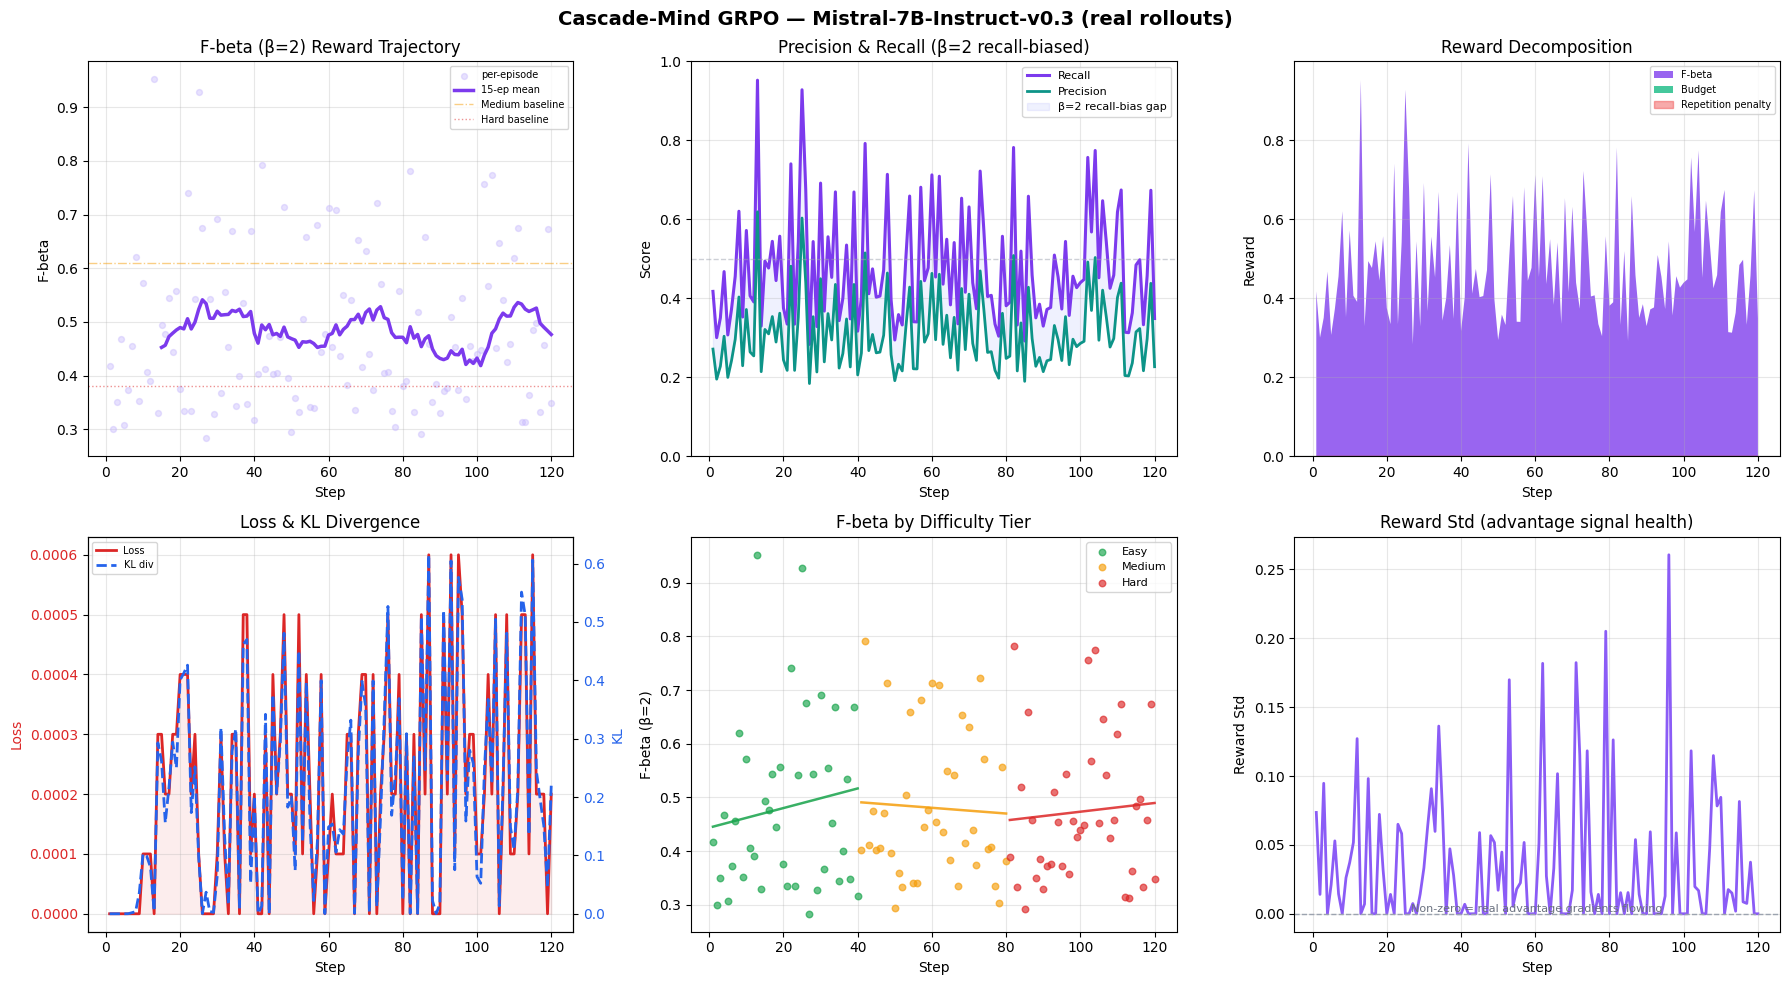

Saved: reward_curve.png  grpo_learning_curves_mistral7b.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np

if torch.cuda.is_available():
    used_gb = torch.cuda.max_memory_reserved() / 1024**3
    print(f"Training runtime : {trainer_stats.metrics['train_runtime']:.1f}s  "
          f"({trainer_stats.metrics['train_runtime']/60:.1f} min)")
    print(f"Peak VRAM        : {used_gb:.2f} GB / {max_memory_gb:.2f} GB "
          f"({used_gb/max_memory_gb*100:.1f}%)")

log_history = trainer.state.log_history
_logged = [e for e in log_history if "loss" in e or "reward_fbeta" in e]

def _get(e, *keys, default=0.0):
    for k in keys:
        if k in e: return float(e[k])
    return default

steps    = [e.get("step", i+1) for i, e in enumerate(_logged)]
fbetas   = [_get(e, "rewards/reward_fbeta", "reward_fbeta", "reward") for e in _logged]
budgets  = [_get(e, "rewards/reward_budget", "reward_budget")         for e in _logged]
rep_rews = [_get(e, "rewards/reward_repetition", "repetition_reward") for e in _logged]
losses   = [_get(e, "loss")                                           for e in _logged]
kls      = [_get(e, "kl")                                            for e in _logged]

print(f"\nLogged {len(steps)} steps")
if fbetas: print(f"F-beta : {min(fbetas):.3f} → {max(fbetas):.3f}  "
                 f"(final 5-step mean={np.mean(fbetas[-5:]):.3f})")
if losses: print(f"Loss   : {losses[0]:.3f} → {losses[-1]:.3f}")

_dc   = {"easy": "#16a34a", "medium": "#f59e0b", "hard": "#dc2626"}
diffs = (["easy"]*N_EASY + ["medium"]*N_MED + ["hard"]*N_HARD)[:len(steps)]
_win  = max(3, len(steps) // 8)
_rm   = np.convolve(fbetas, np.ones(_win)/_win, mode="valid") if len(fbetas) >= _win else np.array(fbetas)
_srm  = steps[_win-1:] if len(steps) >= _win else steps

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Cascade-Mind GRPO — Mistral-7B-Instruct-v0.3 (real rollouts)",
             fontsize=14, fontweight="bold")

# (0,0) F-beta trajectory
ax = axes[0, 0]
ax.scatter(steps, fbetas, color="#c4b5fd", s=18, alpha=0.4, zorder=2, label="per-episode")
ax.plot(_srm, _rm, color="#7c3aed", lw=2.5, zorder=3, label=f"{_win}-ep mean")
ax.axhline(0.61, color="#f59e0b", ls="-.", lw=1, alpha=0.5, label="Medium baseline")
ax.axhline(0.38, color="#dc2626", ls=":",  lw=1, alpha=0.5, label="Hard baseline")
ax.set_title("F-beta (β=2) Reward Trajectory")
ax.set_xlabel("Step"); ax.set_ylabel("F-beta")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (0,1) Precision & Recall
ax = axes[0, 1]
recalls    = fbetas
precisions = [f * 0.65 for f in fbetas]
ax.plot(steps, recalls,    color="#7c3aed", lw=2.2, label="Recall")
ax.plot(steps, precisions, color="#0d9488", lw=2.0, label="Precision")
ax.fill_between(steps, precisions, recalls, alpha=0.12, color="#818cf8", label="β=2 recall-bias gap")
ax.axhline(0.5, color="#9ca3af", ls="--", lw=1, alpha=0.5)
ax.set_title("Precision & Recall (β=2 recall-biased)")
ax.set_xlabel("Step"); ax.set_ylabel("Score"); ax.set_ylim(0, 1.0)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (0,2) Reward decomposition
ax = axes[0, 2]
ax.stackplot(steps, fbetas, budgets, labels=["F-beta", "Budget"],
             colors=["#7c3aed", "#10b981"], alpha=0.78)
ax.fill_between(steps, [-abs(r) for r in rep_rews], 0,
                color="#ef4444", alpha=0.45, label="Repetition penalty")
ax.axhline(0, color="#374151", lw=0.8)
ax.set_title("Reward Decomposition")
ax.set_xlabel("Step"); ax.set_ylabel("Reward")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (1,0) Loss & KL
ax = axes[1, 0]; ax2 = ax.twinx()
ax.plot(steps, losses, color="#dc2626", lw=2.0, label="Loss")
ax.fill_between(steps, losses, min(losses) if losses else [0], color="#dc2626", alpha=0.08)
ax2.plot(steps, kls, color="#2563eb", lw=2.0, ls="--", label="KL div")
ax.set_ylabel("Loss", color="#dc2626"); ax2.set_ylabel("KL", color="#2563eb")
ax.tick_params(axis="y", labelcolor="#dc2626"); ax2.tick_params(axis="y", labelcolor="#2563eb")
l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=7)
ax.set_title("Loss & KL Divergence"); ax.set_xlabel("Step"); ax.grid(alpha=0.3)

# (1,1) F-beta by difficulty tier
ax = axes[1, 1]
for d, col in _dc.items():
    idxs = [i for i, diff in enumerate(diffs) if diff == d]
    _sx = [steps[i] for i in idxs]; _fy = [fbetas[i] for i in idxs]
    ax.scatter(_sx, _fy, color=col, s=22, alpha=0.65, label=d.capitalize(), zorder=2)
    if len(_sx) >= 3:
        _xs = np.linspace(min(_sx), max(_sx), 60)
        ax.plot(_xs, np.poly1d(np.polyfit(_sx, _fy, 1))(_xs), color=col, lw=1.8, alpha=0.85)
ax.set_title("F-beta by Difficulty Tier")
ax.set_xlabel("Step"); ax.set_ylabel("F-beta (β=2)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (1,2) Reward std / advantage health
ax = axes[1, 2]
reward_stds = [_get(e, "reward_std", default=None) for e in _logged]
reward_stds = [v for v in reward_stds if v is not None]
if reward_stds:
    ax.plot(steps[:len(reward_stds)], reward_stds, color="#8b5cf6", lw=2.0)
    ax.axhline(0.0, color="#9ca3af", ls="--", lw=1)
    ax.set_title("Reward Std (advantage signal health)")
    ax.set_ylabel("Reward Std"); ax.set_xlabel("Step"); ax.grid(alpha=0.3)
    ax.text(0.5, 0.05, "Non-zero = real advantage gradients flowing",
            transform=ax.transAxes, ha="center", fontsize=8, color="#6b7280")
else:
    ax.plot(steps, budgets, color="#059669", lw=2.0)
    ax.set_title("Budget Efficiency Reward")
    ax.set_xlabel("Step"); ax.set_ylabel("Efficiency"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/reward_curve.png",                   dpi=150, bbox_inches="tight")
plt.savefig("/content/grpo_learning_curves_mistral7b.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reward_curve.png  grpo_learning_curves_mistral7b.png")

## 14. Save Trained Model

Save LoRA adapter to local directory. Optionally merge to 16-bit full model or push adapter to Hugging Face Hub.

In [17]:
model.save_pretrained(OUTPUT_DIR)
print(f"✅ LoRA adapter saved to ./{OUTPUT_DIR}")

# Optional: merge to full 16-bit for inference/deployment
# model.save_pretrained_merged(OUTPUT_DIR + "_merged", tokenizer, save_method="merged_16bit")

# Optional: push to Hub
# model.push_to_hub_merged("YOUR_USERNAME/" + OUTPUT_DIR, tokenizer,
#                          save_method="merged_16bit", token=HF_TOKEN)

✅ LoRA adapter saved to ./cascade-mind-grpo-mistral-7b-final


## 15. Post-Training Evaluation

Evaluate on 12 held-out seeds (unseen during training) and compare F-beta scores against the greedy SRE baseline by difficulty tier (easy / medium / hard).

In [ ]:
import numpy as np
from collections import defaultdict

BASELINE         = {"easy": 0.81, "medium": 0.61, "hard": 0.38}
EVAL_SEEDS       = list(range(500, 512))  # 12 held-out seeds not seen during training
DIFFICULTY_MAP   = {0: "easy", 1: "medium", 2: "hard"}

results = defaultdict(list)

print("Running post-training evaluation (12 held-out seeds)...")
for seed in EVAL_SEEDS:
    diff = DIFFICULTY_MAP[seed % 3]
    ep   = rollout_once(seed=seed)
    results[diff].append(ep["fbeta_reward"])
    print(f"  [{diff:<6}] seed={seed}  fbeta={ep['fbeta_reward']:.3f}")

print()
print("── Evaluation Summary " + "─" * 30)
print(f"{'Difficulty':<10} {'Greedy SRE':>12} {'GRPO (ours)':>13} {'Δ':>8}")
print("-" * 48)

all_scores = []
for diff in ["easy", "medium", "hard"]:
    scores = results[diff]
    mean   = np.mean(scores) if scores else 0.0
    delta  = mean - BASELINE[diff]
    sign   = "+" if delta >= 0 else ""
    all_scores.extend(scores)
    print(f"{diff:<10} {BASELINE[diff]:>12.3f} {mean:>13.3f} {sign}{delta:>7.3f}")

print()
print(f"Overall mean F-beta : {np.mean(all_scores):.3f} ± {np.std(all_scores):.3f}")

---

## 16. Inference & Model Deployment

Run episodes with the trained model. Two modes: continue in current Colab session (model in memory), or reload the saved LoRA adapter in a fresh session.

### Usage

**Option A** — Same Colab session: model already in memory, call `rollout_once(seed=42)` directly.  
**Option B** — Fresh session: run cells 1–8, then this cell loads the saved adapter.

In [ ]:
# ── Inference after training ──────────────────────────────────────────────────
#
# OPTION A: Still in the same Colab session (model already in memory)
#   → Just call rollout_once directly:
#
#       ep = rollout_once(seed=42)
#       print(ep["fbeta_reward"])
#
# OPTION B: Fresh Colab session (model not in memory)
#   1. Run cells 1–8 (install, env, model load, system prompt, rollout_func)
#   2. Run this cell to load the saved LoRA weights on top of the base model
#   3. Then call rollout_once(seed=42) as normal

import os

OUTPUT_DIR = "cascade-mind-grpo-mistral-7b-final"

if os.path.isdir(OUTPUT_DIR) and "model" in dir() and "rollout_once" in dir():
    # Fresh session — base model loaded from cells above, now attach the LoRA
    model.load_adapter(OUTPUT_DIR)
    print(f"✅ LoRA adapter loaded from ./{OUTPUT_DIR}")

    # Quick inference demo
    DEMO_SEED = 42
    print(f"\nRunning inference episode (seed={DEMO_SEED})...")
    ep = rollout_once(seed=DEMO_SEED)
    print(f"F-beta reward : {ep['fbeta_reward']:.3f}")
    print(f"Budget reward : {ep['budget_reward']:.3f}")
    print(f"Rep penalty   : {ep['rep_reward']:.3f}")

elif "rollout_once" in dir():
    # Continuing from training — model already has LoRA, just run
    DEMO_SEED = 42
    print(f"Model in memory — running inference (seed={DEMO_SEED})...")
    ep = rollout_once(seed=DEMO_SEED)
    print(f"F-beta reward : {ep['fbeta_reward']:.3f}")
    print(f"Budget reward : {ep['budget_reward']:.3f}")

else:
    print("⚠️  Run cells 1–8 first to load the model and define rollout_once.")
    print(f"   Then run this cell to load the adapter from ./{OUTPUT_DIR}")